In [105]:
import pandas as pd 
import matplotlib.pyplot as plt 
import ast
import numpy as np 
import seaborn as sns



dataset = pd.read_csv('/Users/tajveer/Downloads/data_jobs.csv')
df = pd.DataFrame(dataset)
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list)if pd.notna(skill_list) else skill_list)
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])


In [106]:
df_us = df[df['job_country']== 'United States']
df_skills= df_us.explode('job_skills')
df_skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
245,clojure,Software Engineer,1
1738,vb.net,Senior Data Scientist,1
530,fortran,Machine Learning Engineer,1
1116,planner,Cloud Engineer,1


In [107]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])

In [108]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x )
    
    df_plot.plot(kind='barh', x= 'job_skills', y= 'skill_count', ax=ax[i], title=job_title)

SyntaxError: positional argument follows keyword argument (3328908873.py, line 5)

In [ ]:
df_job_title_count = df_us['job_title_short'].value_counts().reset_index()

In [ ]:
df_skills_percent=pd.merge(df_skills_count,df_job_title_count, how= 'left', on= 'job_title_short')
df_skills_percent

,job_skills,job_title_short,skill_count,count
0,python,Data Scientist,42379,58830
1,sql,Data Analyst,34452,67816
2,sql,Data Scientist,30034,58830
3,excel,Data Analyst,27519,67816
4,r,Data Scientist,26022,58830
...,...,...,...,...
1865,clojure,Software Engineer,1,1814
1866,vb.net,Senior Data Scientist,1,12946
1867,fortran,Machine Learning Engineer,1,921
1868,planner,Cloud Engineer,1,423


In [ ]:
df_skills_percent['skill_percent']= (df_skills_percent['skill_count']/df_skills_percent['count'])*100
df_skills_percent

,job_skills,job_title_short,skill_count,count,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,clojure,Software Engineer,1,1814,0.055127
1866,vb.net,Senior Data Scientist,1,12946,0.007724
1867,fortran,Machine Learning Engineer,1,921,0.108578
1868,planner,Cloud Engineer,1,423,0.236407


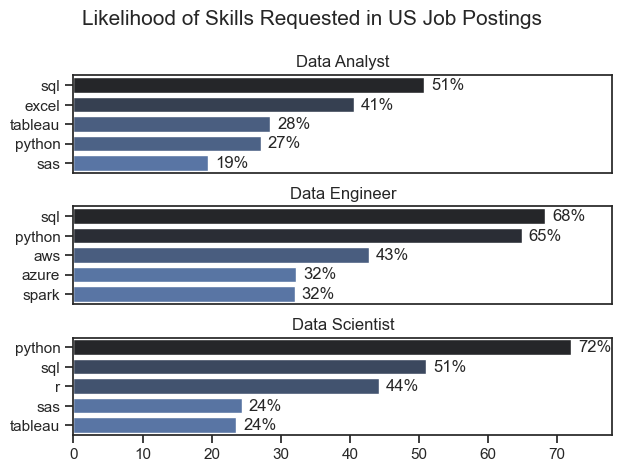

In [109]:
fig, ax = plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_percent[df_skills_percent['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    # sns.barplot(data=df_plot, x )
    
    # df_plot.plot(kind='barh', x= 'job_skills', y= 'skill_percent', ax=ax[i], title=job_title)
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0,78)
  


    if i != len(job_titles)-1:
       ax[i].set_xticks([])


    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v+1,n, f'{v:.0f}%', va='center')

    if i != len(job_titles)-1:
        ax[i].set_xticks([])

            
    fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()


 # make the scales the same
